# GPU Acceleration with pyUDE

pyUDE supports GPU-accelerated training on NVIDIA (CUDA) and Apple Silicon (MPS) hardware
through PyTorch's native device support. The `device` parameter is set at model construction
and applies automatically to all training and inference operations.

This notebook covers:
1. Detecting available devices
2. Training NODE on GPU
3. Training CustomDerivatives on GPU
4. Training CustomDifferences on GPU
5. CPU vs GPU speed comparison
6. Best practices and tips

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display

import time
import numpy as np
import pandas as pd
import torch

import pyUDE as ude

torch.manual_seed(42)
np.random.seed(42)

print(f"pyUDE version : {ude.__version__}")
print(f"PyTorch version: {torch.__version__}")

pyUDE version : 0.0.2
PyTorch version: 2.11.0+cu126


## 1. Detecting available devices

In [2]:
cuda_available = torch.cuda.is_available()
mps_available  = torch.backends.mps.is_available()

print(f"CUDA available : {cuda_available}")
if cuda_available:
    print(f"  GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"MPS available  : {mps_available}")

# Detect CPU-only PyTorch when an NVIDIA GPU is present on the system
if not cuda_available and torch.version.cuda is None:
    import subprocess
    try:
        smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=5)
        if smi.returncode == 0:
            print("\n" + "="*60)
            print("WARNING: An NVIDIA GPU was detected but PyTorch was installed")
            print(f"without CUDA support (torch version: {torch.__version__}).")
            print()
            print("Fix — reinstall PyTorch with CUDA:")
            print()
            print("  pip uninstall torch torchdiffeq -y")
            print("  pip install torch --index-url https://download.pytorch.org/whl/cu126")
            print("  pip install torchdiffeq")
            print()
            print("Then restart the kernel and re-run this notebook.")
            print("See: https://pytorch.org/get-started/locally/")
            print("="*60 + "\n")
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass  # nvidia-smi not on PATH — cannot determine GPU presence

# Select the best device automatically
def best_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = best_device()

# MPS does not support float64, which pyUDE uses internally — fall back to CPU
if DEVICE == "mps":
    print("Note: MPS detected but pyUDE requires float64 tensors, which MPS does not support.")
    print("      Falling back to CPU. For GPU acceleration use a CUDA-enabled device.")
    DEVICE = "cpu"

print(f"Using device   : {DEVICE}")

CUDA available : True
  GPU name     : NVIDIA GeForce RTX 4080 Laptop GPU
  VRAM         : 12.9 GB
MPS available  : False
Using device   : cuda


## 2. Synthetic data

We simulate a Lotka-Volterra predator-prey system to use throughout the notebook.

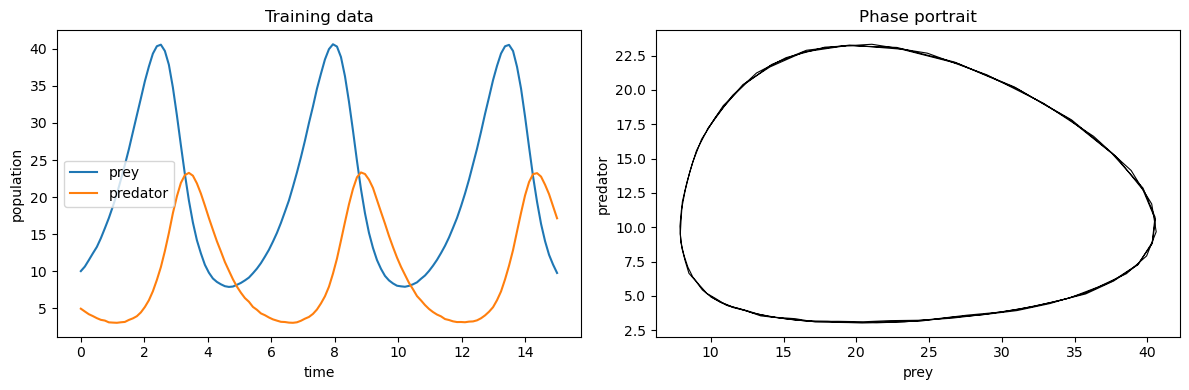

Data shape: (120, 3)


In [3]:
def simulate_lv(t_end=15, n=120, alpha=1.0, beta=0.1, delta=0.075, gamma=1.5, seed=42):
    """Accurate Lotka-Volterra data via scipy (avoids Euler drift)."""
    from scipy.integrate import solve_ivp
    def rhs(t, u):
        prey, pred = u
        return [alpha * prey - beta * prey * pred,
                delta * prey * pred - gamma * pred]
    sol = solve_ivp(rhs, [0, t_end], [10.0, 5.0],
                    t_eval=np.linspace(0, t_end, n),
                    method="RK45", rtol=1e-8, atol=1e-10)
    rng = np.random.default_rng(seed)
    prey = np.maximum(sol.y[0] + 0.05 * rng.standard_normal(n), 0.01)
    pred = np.maximum(sol.y[1] + 0.05 * rng.standard_normal(n), 0.01)
    return pd.DataFrame({"time": sol.t, "prey": prey, "predator": pred})

data = simulate_lv()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(data["time"], data["prey"],     label="prey")
axes[0].plot(data["time"], data["predator"], label="predator")
axes[0].set(xlabel="time", ylabel="population", title="Training data")
axes[0].legend()
axes[1].plot(data["prey"], data["predator"], "k", lw=0.8)
axes[1].set(xlabel="prey", ylabel="predator", title="Phase portrait")
plt.tight_layout()
display(fig)
plt.close(fig)
print(f"Data shape: {data.shape}")

## 3. NODE on GPU

Pass `device=DEVICE` to the constructor. Everything else is identical to CPU usage.

In [4]:
node = ude.NODE(
    data,
    hidden_units=64,
    hidden_layers=3,
    device=DEVICE,
)
print(node)   # __repr__ shows device

NODE(states=2, columns=['prey', 'predator'], device='cuda', untrained)


In [5]:
t0 = time.perf_counter()
node.train(
    loss="simulation",
    epochs=300,
    learning_rate=1e-3,
    log_interval=100,
    patience=50,        # early stopping
    max_grad_norm=5.0,  # gradient clipping
)
t1 = time.perf_counter()
print(f"\nTraining time ({DEVICE}): {t1 - t0:.1f}s")

Epoch   100/300  loss=88.313159
Epoch   200/300  loss=82.799879
Epoch   300/300  loss=80.140284

Training time (cuda): 948.5s


In [6]:
# Verify that model parameters live on the chosen device
param_device = next(node._ode_func.parameters()).device
print(f"Model parameters on: {param_device}")

# Forecast always returns a CPU DataFrame, regardless of training device
forecast = node.forecast(steps=40)
print(f"Forecast type: {type(forecast)}")
print(forecast.head(3))

Model parameters on: cuda:0
Forecast type: <class 'pandas.core.frame.DataFrame'>
        time       prey   predator
0  15.126050  10.839496  17.564969
1  15.252101  11.925952  17.994300
2  15.378151  13.022590  18.426709


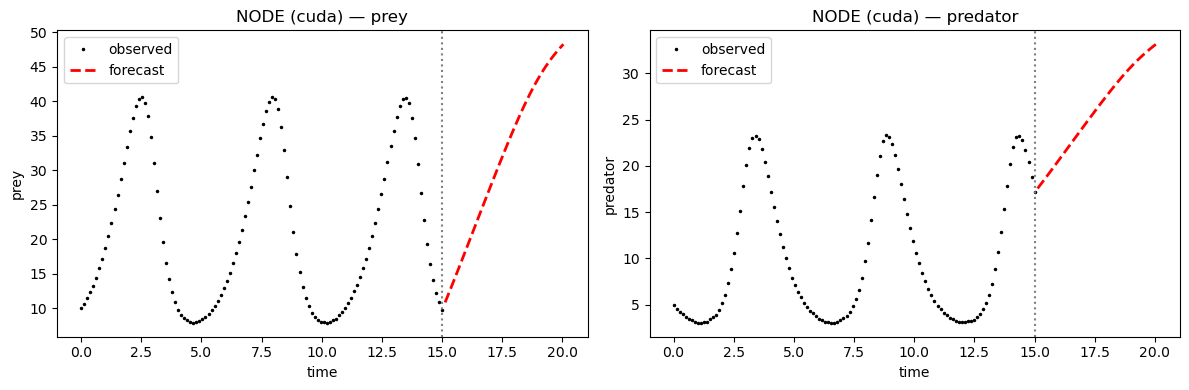

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["prey", "predator"]):
    ax.plot(data["time"],     data[col],     "k.",  ms=3,  label="observed")
    ax.plot(forecast["time"], forecast[col], "r--", lw=2,  label="forecast")
    ax.axvline(data["time"].iloc[-1], color="gray", ls=":")
    ax.set(xlabel="time", ylabel=col, title=f"NODE ({DEVICE}) — {col}")
    ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 4. CustomDerivatives on GPU

Hybrid UDE: encode prey growth and predator death as known; let the network learn predation.

In [8]:
def lv_known(u, p, t):
    """Known terms: exponential prey growth + linear predator death."""
    prey, pred = u[0], u[1]
    return torch.stack([
        p["alpha"] * prey,    # prey grows
        -p["delta"] * pred,   # predator dies without prey
    ])

hybrid = ude.CustomDerivatives(
    data,
    known_dynamics=lv_known,
    init_params={"alpha": 0.8, "delta": 1.2},
    hidden_units=32,
    device=DEVICE,
)
print(hybrid)

CustomDerivatives(states=2, columns=['prey', 'predator'], device='cuda', untrained)


In [ ]:
# Stage 1: coarse pass with simulation loss
hybrid.train(epochs=200, learning_rate=3e-3, log_interval=100)

# Stage 2: fine-tune — continues from existing weights (additive training)
hybrid.train(epochs=300, learning_rate=5e-4, log_interval=100, patience=40)

Epoch   100/200  loss=226.509924
Epoch   200/200  loss=128.617739


In [ ]:
params = hybrid.get_params()
print("Recovered parameters:")
print(f"  alpha = {params['alpha']:.4f}  (true: 1.000)")
print(f"  delta = {params['delta']:.4f}  (true: 1.500)")

fc_hybrid = hybrid.forecast(steps=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["prey", "predator"]):
    ax.plot(data["time"],        data[col],        "k.",  ms=3, label="observed")
    ax.plot(fc_hybrid["time"],   fc_hybrid[col],   "b--", lw=2, label="forecast")
    ax.axvline(data["time"].iloc[-1], color="gray", ls=":")
    ax.set(xlabel="time", ylabel=col, title=f"CustomDerivatives ({DEVICE}) — {col}")
    ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 5. CustomDifferences on GPU

Discrete-time model on a logistic map.

In [ ]:
# Generate logistic map data  (r = 3.6)
x = 0.5
xs = []
for _ in range(150):
    xs.append(x)
    x = 3.6 * x * (1 - x)
map_data = pd.DataFrame({"time": np.arange(150, dtype=float), "x": xs})

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(map_data["time"], map_data["x"], "k.", ms=3)
ax.set(title="Logistic map (r=3.6) — training data", xlabel="step", ylabel="x")
plt.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
def logistic_known(u, p, t):
    """Known logistic structure; r is learned."""
    return p["r"] * u * (1 - u)

diff_model = ude.CustomDifferences(
    map_data,
    known_map=logistic_known,
    init_params={"r": 3.0},   # true value is 3.6
    hidden_units=16,
    device=DEVICE,
)
print(diff_model)

In [ ]:
diff_model.train(epochs=800, log_interval=200, patience=80)

print(f"Learned r = {diff_model.get_params()['r']:.4f}  (true: 3.600)")

fc_diff = diff_model.forecast(steps=30)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(map_data["time"], map_data["x"], "k.", ms=3, label="training data")
ax.plot(fc_diff["time"],  fc_diff["x"],  "r.", ms=3, label="forecast")
ax.axvline(map_data["time"].iloc[-1], color="gray", ls=":")
ax.set(title=f"CustomDifferences ({DEVICE}) — logistic map", xlabel="step", ylabel="x")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 6. CPU vs GPU speed comparison

Whether GPU training is faster than CPU depends on **network size** — not the device itself.
The ODE solver makes many small sequential calls to the neural network (one per adaptive step),
so the GPU only wins when those individual matmuls are large enough to amortise kernel launch
overhead.

**Methodology notes:**
- A **warmup run** is discarded before timing to avoid JIT compilation overhead.
- `torch.cuda.synchronize()` is called before and after timing to ensure all GPU work
  is complete before reading the clock (CUDA operations are asynchronous by default).
- **Best-of-3** trials are reported to remove OS scheduling noise.

In [ ]:
EPOCHS = 50
N_TRIALS = 3   # best-of-N to remove scheduling noise


def time_training(device, hidden_units=128, epochs=EPOCHS, loss="simulation"):
    """Return best-of-N per-epoch time in milliseconds (warmup discarded)."""
    times = []
    for trial in range(N_TRIALS + 1):   # trial 0 = warmup
        model = ude.NODE(data, hidden_units=hidden_units, hidden_layers=4, device=device)

        if device == "cuda":
            torch.cuda.synchronize()   # flush any pending GPU work

        t0 = time.perf_counter()
        model.train(loss=loss, epochs=epochs, verbose=False)

        if device == "cuda":
            torch.cuda.synchronize()   # wait for all GPU kernels to finish

        elapsed = time.perf_counter() - t0

        if device == "cuda":
            torch.cuda.empty_cache()
        del model

        if trial > 0:                  # skip warmup
            times.append(elapsed)

    return 1000 * min(times) / epochs  # ms per epoch (best trial)


# --- Run the sweep ---
hidden_sizes = [64, 128, 256, 512]

print(f"{'hidden':>8} | {'CPU ms/ep':>12} | {'GPU ms/ep':>12} | {'speedup':>10}")
print("-" * 52)

cpu_times, gpu_times, speedups = [], [], []

for hidden in hidden_sizes:
    cpu_ms = time_training("cpu", hidden_units=hidden)
    cpu_times.append(cpu_ms)

    if DEVICE != "cpu":
        gpu_ms = time_training(DEVICE, hidden_units=hidden)
        gpu_times.append(gpu_ms)
        sp = cpu_ms / gpu_ms
        speedups.append(sp)
        tag = "GPU faster" if sp > 1.05 else ("CPU faster" if sp < 0.95 else "roughly equal")
        print(f"{hidden:>8} | {cpu_ms:>10.1f}ms | {gpu_ms:>10.1f}ms | {sp:>8.2f}x  ({tag})")
    else:
        print(f"{hidden:>8} | {cpu_ms:>10.1f}ms | {'—':>12} | {'—':>10}")

if DEVICE == "cpu":
    print("\nNo GPU available — only CPU results shown.")

### Why the speedup is limited for small UDE models

The table above typically shows little or no GPU advantage below `hidden_units=256`. Three
structural reasons explain this:

**1. Sequential ODE integration**
`odeint_adjoint` integrates one trajectory step-by-step. Each adaptive solver step calls
`network(u)` on a single state vector `u` of shape `(n_states,)` — for our 2-state system,
that is just 2 floats. GPU parallelism only helps *within* that single matmul, which is far
too small to amortise the ~5–10 µs kernel launch cost.

**2. Tiny matmuls**
A `2 → 64 → 64 → 2` network processes input of shape `(2,)`. The dominant layer is
`64 × 64 = 4096` multiply-adds — performed thousands of times per epoch. An RTX 4080 can do
~165 TFLOPS but only when fed large batches; a single `(64,)` vector keeps ≈0.01% of its
cores busy.

**3. CPU data is cache-resident**
Our 120-point, 2-state trajectory is ~2 KB. It fits entirely in L1 CPU cache, so CPU memory
bandwidth is not a bottleneck — GPU's bandwidth advantage does not apply.

**When GPU does win:** network width ≥ 256, derivative-matching loss (vectorised with
`torch.vmap`), or long trajectories (500+ steps). See the next cell.

In [ ]:
if DEVICE != "cpu":
    print("=== Configuration A: large network, simulation loss ===")
    print("(GPU wins when the network is wide enough for matmuls to dominate launch overhead)\n")

    for hidden in [256, 512]:
        cpu_ms = time_training("cpu", hidden_units=hidden)
        gpu_ms = time_training(DEVICE, hidden_units=hidden)
        sp = cpu_ms / gpu_ms
        print(f"  hidden={hidden}  CPU: {cpu_ms:.1f} ms/ep  GPU: {gpu_ms:.1f} ms/ep  → {sp:.1f}x speedup")

    print()
    print("=== Configuration B: derivative-matching loss (torch.vmap) ===")
    print("(DM loss batches all T time-point evaluations into one GPU call via vmap)\n")

    for hidden in [64, 128, 256]:
        cpu_ms = time_training("cpu",  hidden_units=hidden, loss="derivative_matching")
        gpu_ms = time_training(DEVICE, hidden_units=hidden, loss="derivative_matching")
        sp = cpu_ms / gpu_ms
        print(f"  hidden={hidden}  CPU: {cpu_ms:.1f} ms/ep  GPU: {gpu_ms:.1f} ms/ep  → {sp:.1f}x speedup")

    print()
    print("Takeaway: DM loss benefits from GPU at smaller network sizes than simulation loss,")
    print("because vmap turns T sequential calls into one batched GPU operation.")
else:
    print("No GPU available — skipping GPU-wins demonstration.")

## 7. Additive (incremental) training on GPU

Calling `train()` multiple times on the same model continues from the current weights. This
works identically on GPU and CPU.

In [ ]:
staged = ude.NODE(data, hidden_units=64, device=DEVICE)

print("=== Stage 1: coarse pass ===")
staged.train(epochs=100, learning_rate=1e-3, log_interval=50)

print("\n=== Stage 2: fine-tune (continues from Stage 1 weights) ===")
staged.train(epochs=200, learning_rate=2e-4, log_interval=50)

print("\n=== Stage 3: final polish ===")
staged.train(epochs=100, learning_rate=5e-5, log_interval=50)

fc_staged = staged.forecast(steps=40)
print("\nForecast shape:", fc_staged.shape)

## 9. Tips and best practices

### Choosing a device

```python
def best_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"
```

### When GPU helps — and when it doesn't

GPU acceleration applies *within* each ODE function evaluation (a small neural network
forward pass). Because ODE integration is inherently sequential, GPU parallelism is limited
to the matmul operations inside each call. This means:

| Configuration | Expected GPU speedup |
|---------------|----------------------|
| `hidden_units < 128`, simulation loss, short sequence | None or negative — use CPU |
| `hidden_units ≥ 256`, simulation loss | 2–6× depending on network size |
| Any size, `loss="derivative_matching"` | 2–4× (vmap batches all T evaluations into one GPU call) |
| `hidden_units ≥ 256`, long sequence (500+ steps) | 5–10× |

**Minimum recommended configuration for GPU (simulation loss):**

```python
# GPU worth using at this size and above
model = ude.NODE(data, hidden_units=256, hidden_layers=4, device="cuda")
model.train(loss="simulation", epochs=1000)
```

**GPU benefit with smaller networks (derivative-matching warm-up):**

```python
# DM loss benefits from GPU at smaller sizes — good for warm-up phases
model = ude.NODE(data, hidden_units=128, device="cuda")
model.train(loss="derivative_matching", epochs=500)   # GPU helps here
model.train(loss="simulation",          epochs=500)   # marginal unless hidden ≥ 256
```

### `known_dynamics` with GPU tensors

When training on GPU, `u`, the parameter dict `p`, and `t` passed to your `known_dynamics`
function will be on the device. Standard `torch` operations work transparently:

```python
def lv_known(u, p, t):
    # u, p values, and t are all on the same device as the model — no change needed
    return torch.stack([p["alpha"] * u[0], -p["delta"] * u[1]])
```

Avoid calling `.numpy()` inside `known_dynamics` — numpy does not support GPU tensors.

### Benchmark timing: always synchronize

Wall-clock time measured without `torch.cuda.synchronize()` is unreliable for GPU:

```python
# Correct GPU timing
torch.cuda.synchronize()
t0 = time.perf_counter()
model.train(epochs=100, verbose=False)
torch.cuda.synchronize()
elapsed = time.perf_counter() - t0
```

Also discard the first run (JIT warmup) and take the best of several trials.

### Forecast always returns CPU output

`model.forecast()` moves tensors back to CPU before constructing the output DataFrame, so
downstream code (matplotlib, pandas, scipy) works unchanged regardless of training device.

In [ ]:
import tempfile, os

with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as f:
    path = f.name

node.save(path)
print(f"Saved to: {path}")
print(f"File size: {os.path.getsize(path) / 1024:.1f} KB")

# Load checkpoint (to CPU, regardless of which device trained it)
checkpoint = torch.load(path, map_location="cpu", weights_only=False)
print("\nCheckpoint keys:", list(checkpoint.keys()))
os.unlink(path)

## 9. Tips and best practices

### Choosing a device

```python
def best_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"
```

### When GPU helps most

| Scenario | Expected speedup |
|----------|----------------|
| Large MLP (128+ units, 4+ layers) | High |
| Long trajectories (200+ time steps) | High |
| Small MLP + short trajectory | Low / negative |
| `derivative_matching` loss | Moderate (no ODE integration) |

### `known_dynamics` with GPU tensors

When training on GPU, the `u`, `p`, and `t` tensors passed to your `known_dynamics` function
will be on the device. Standard `torch` operations work transparently:

```python
def lv_known(u, p, t):
    # u, p values, t are all on the same device as the model — no change needed
    return torch.stack([p["alpha"] * u[0], -p["delta"] * u[1]])
```

Avoid calling `.numpy()` inside `known_dynamics` — numpy does not support GPU tensors.

### Forecast always returns CPU output

`model.forecast()` moves tensors back to CPU before constructing the output DataFrame, so
downstream code (matplotlib, pandas, scipy) works unchanged regardless of training device.

In [ ]:
# Confirm: forecast is always a plain CPU DataFrame
fc = node.forecast(steps=10)
print(type(fc))
print(fc.dtypes)